#Библиотеки

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#EDA

In [ ]:
df = pd.read_excel("base.xlsx")
df

,Номер студента,Сумма,Курс,Время
0,437,8950.0,ML про,2026-08-04 09:08:31
1,437,7890.0,Аналитика старт,2026-08-04 09:35:00
2,443,8475.0,Линейная алгебра,2026-08-04 10:14:38
3,443,8475.0,Мат анализ,2026-08-04 10:14:38
4,430,8950.0,К ВУЗу,2026-08-04 13:38:06
...,...,...,...,...
790,36,8950.0,Линейная алгебра,2026-09-09 19:26:20
791,36,8950.0,Мат анализ,2026-09-09 19:26:20
792,36,8950.0,Теория вероятностей,2026-09-09 19:26:20
793,407,8950.0,Линейная алгебра,2026-09-09 23:11:20


In [ ]:
df = df.rename(columns={
    "Номер студента": "id",
    "Сумма": "amount", 'Курс': 'course', 'Время': 'datetime'
})

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 795 entries, 0 to 794
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   id        795 non-null    int64         
 1   amount    795 non-null    float64       
 2   course    795 non-null    object        
 3   datetime  795 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 25.0+ KB


In [ ]:
df.dtypes

,0
id,int64
amount,float64
course,object
datetime,datetime64[ns]


In [ ]:
rev_by_day = df.groupby(df['datetime'].dt.date).agg({'amount': 'sum'}).sort_values('datetime', ascending=True)
rev_by_day

,amount
datetime,
2026-08-04,84130.00
2026-08-05,67110.00
2026-08-06,62445.00
2026-08-07,54995.00
2026-08-08,275015.00
2026-08-09,524091.67
2026-08-10,205590.00
2026-08-11,96330.00
2026-08-12,114930.00


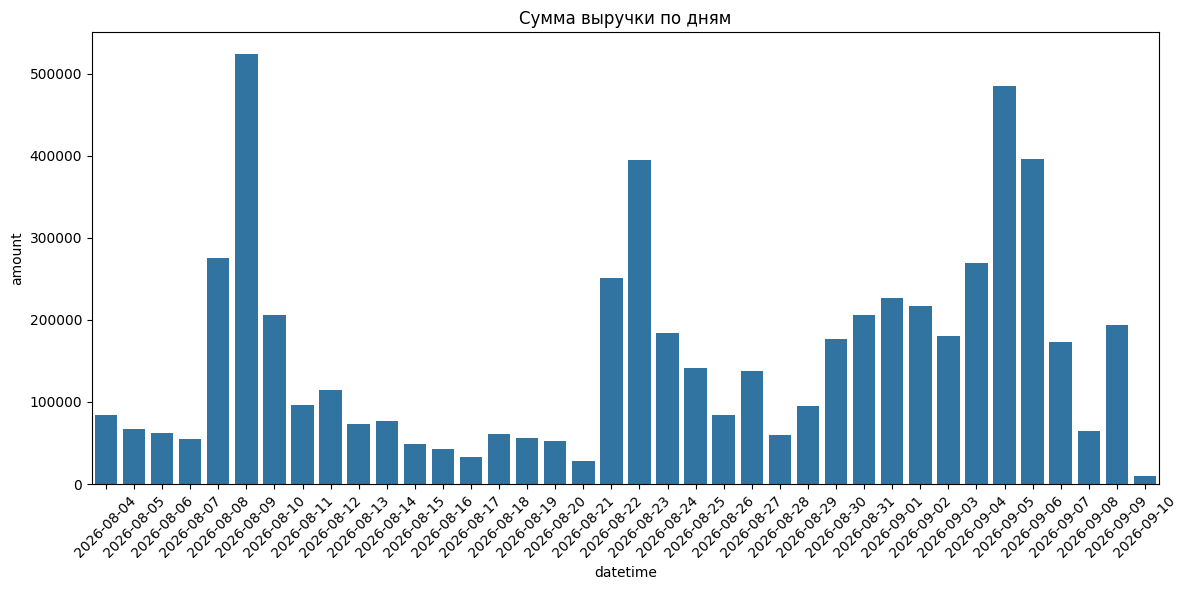

In [ ]:
plt.figure(figsize=(12, 6))
plt.title('Сумма выручки по дням')
sns.barplot(data=rev_by_day, x="datetime", y="amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#Топ 10 дней по выручке
rev_by_day.sort_values('amount', ascending=False).head(10)

,amount
datetime,
2026-08-09,524091.67
2026-09-05,484684.00
2026-09-06,396075.00
2026-08-23,394495.00
2026-08-08,275015.00
2026-09-04,269585.00
2026-08-22,251150.00
2026-09-01,226880.00
2026-09-02,217280.00


In [ ]:
rev_by_day_of_week = df.groupby(df['datetime'].dt.dayofweek).agg({'amount': 'sum'}).sort_values('datetime', ascending=True).rename(index={
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
})
rev_by_day_of_week

,amount
datetime,
Monday,802411.00
Tuesday,674850.00
Wednesday,733375.00
Thursday,515615.00
Friday,489615.00
Saturday,1154719.00
Sunday,1534086.67


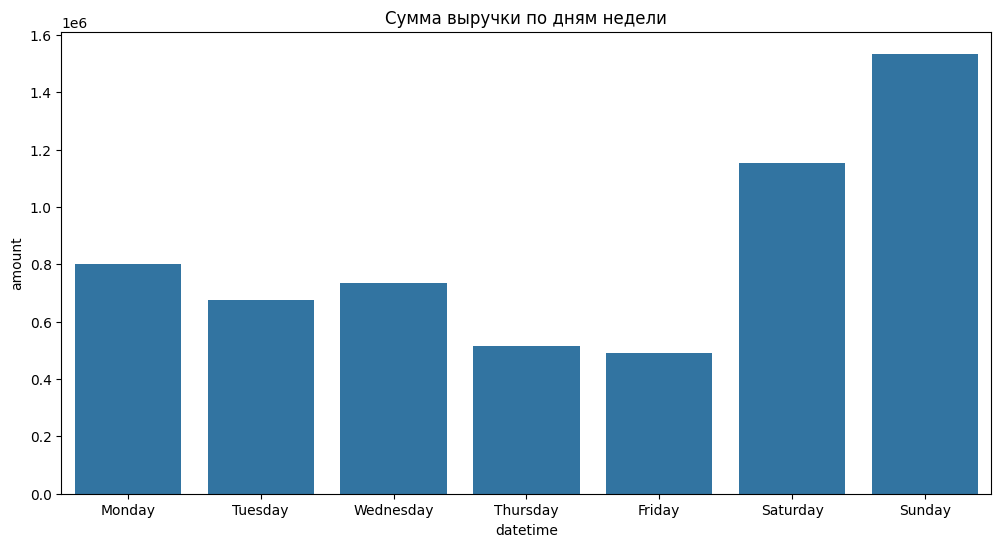

In [ ]:
plt.figure(figsize=(12, 6))
plt.title('Сумма выручки по дням недели')
sns.barplot(data=rev_by_day_of_week, x="datetime", y="amount")
plt.show()

In [ ]:
rev_by_hour = df.groupby(df['datetime'].dt.hour).agg({'amount': 'sum'}).sort_values('datetime', ascending=True)
rev_by_hour

,amount
datetime,
0,33775.00
1,22400.00
2,46810.00
3,20450.00
4,147880.00
5,71865.00
6,145765.00
7,138083.00
8,154980.00


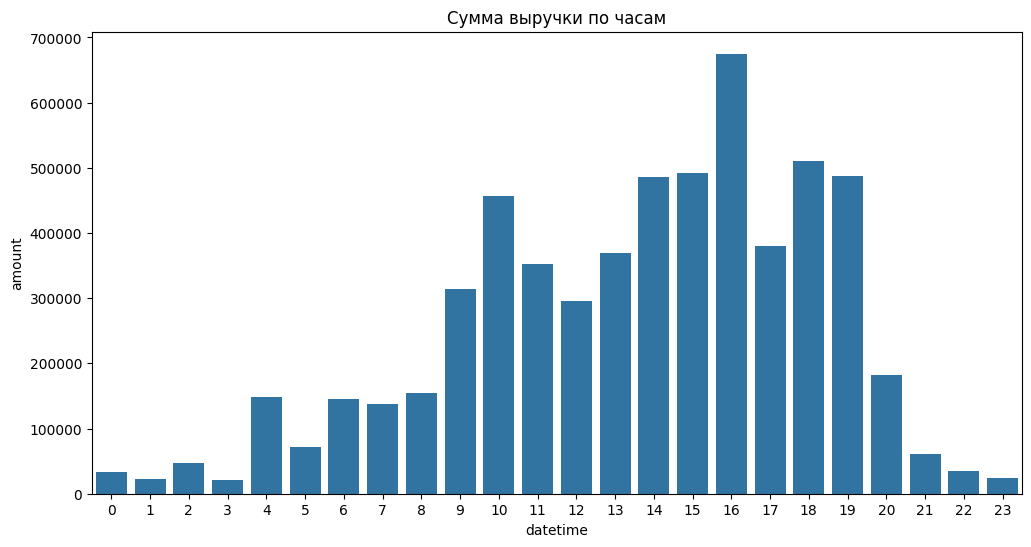

In [ ]:
plt.figure(figsize=(12, 6))
plt.title('Сумма выручки по часам')
sns.barplot(data=rev_by_hour, x="datetime", y="amount")
plt.show()

In [ ]:
df.course.nunique()

18

In [ ]:
rev_by_course = df.groupby(df['course']).agg({'amount': 'sum'}).sort_values('amount', ascending=False)
rev_by_course

,amount
course,
Аналитика про,740941.50
ML про,715110.00
AI агенты,711673.00
Аналитика старт,641616.50
Алгоритмы старт,529851.68
ML старт,523278.33
Backend про,438342.50
Алгоритмы про,268409.00
Backend старт,263396.66


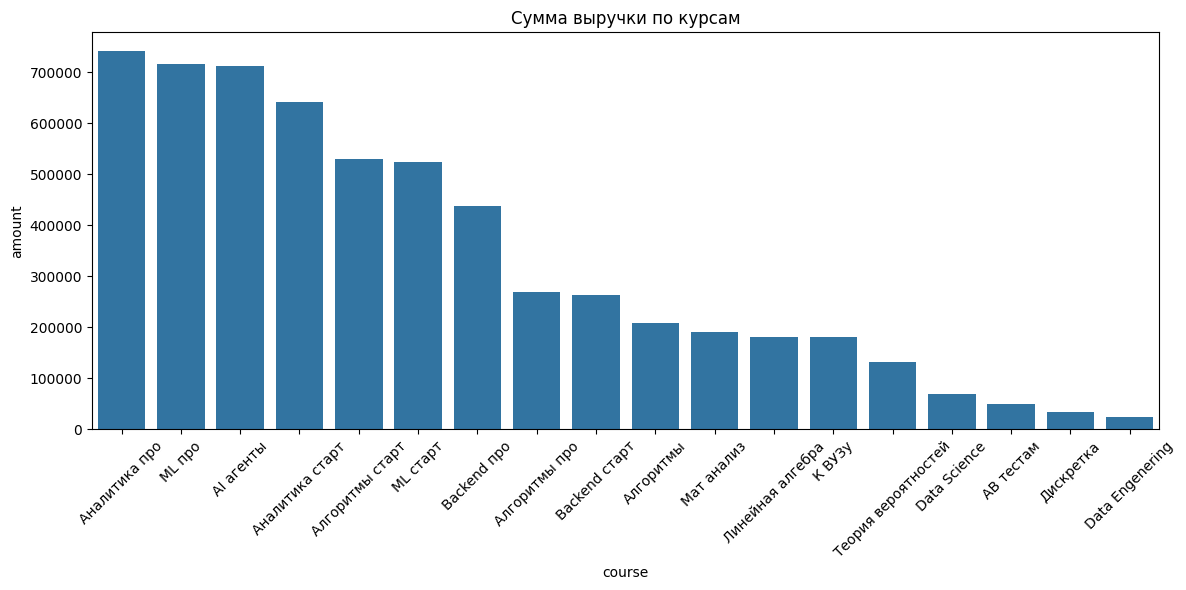

In [ ]:
plt.figure(figsize=(12, 6))
plt.title('Сумма выручки по курсам')
sns.barplot(data=rev_by_course, x="course", y="amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#
quantity_by_id = df.groupby('id', as_index = False).agg({'amount': 'count'}).sort_values('amount', ascending=False)
quantity_by_id

,id,amount
600,601,5
230,231,5
35,36,5
190,191,4
436,437,4
...,...,...
225,226,1
224,225,1
223,224,1
222,223,1


In [ ]:
a = quantity_by_id.query('amount > 1')
a['amount'].mode()


,amount
0,2


In [ ]:
df['id'].nunique()

606

In [ ]:
df['id']

,id
0,437
1,437
2,443
3,443
4,430
...,...
790,36
791,36
792,36
793,407


In [ ]:
avg_amount_on_course = df.groupby('course', as_index=False)['amount'].mean().sort_values('amount', ascending=False)
avg_amount_on_course

,course,amount
17,Теория вероятностей,10162.115385
16,Мат анализ,9569.125000
15,Линейная алгебра,9508.684211
13,Дискретка,8603.750000
1,Backend про,7969.863636
11,Аналитика про,7967.112903
5,ML про,7945.666667
0,AI агенты,7820.582418
4,Data Science,7699.444444
9,Алгоритмы про,7668.828571


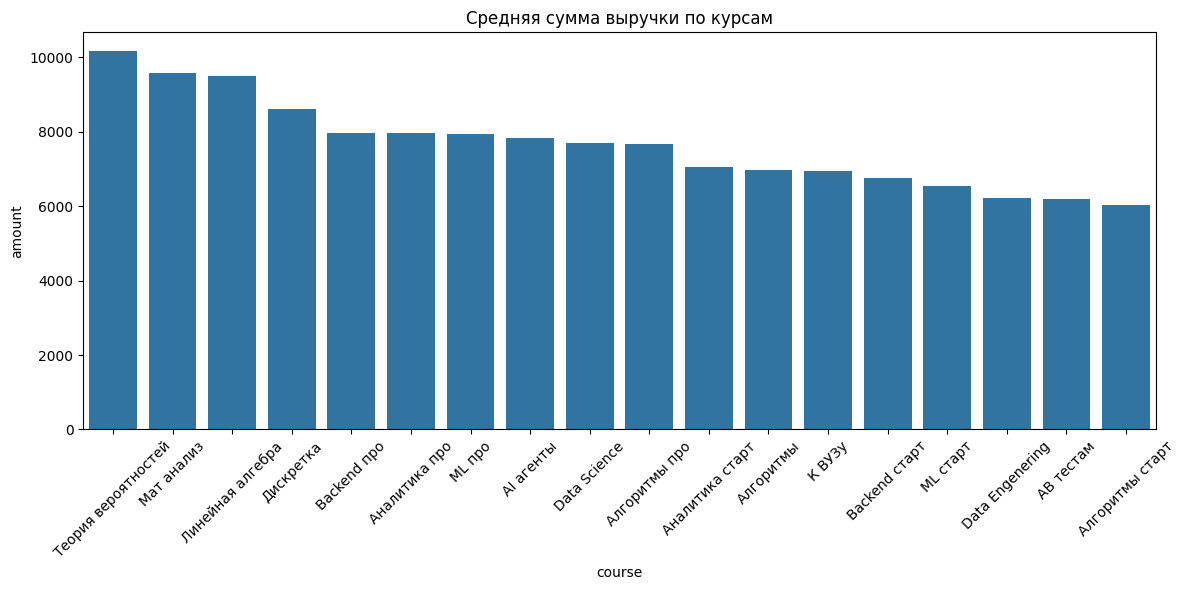

In [ ]:
plt.figure(figsize=(12, 6))
plt.title('Средняя сумма выручки по курсам')
sns.barplot(avg_amount_on_course, x="course", y="amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.bar_label
plt.show()

In [1]:
# Проверка доступности исходных данных (ознакомление с кейсом)
from pathlib import Path
base_files = list(Path('/content').rglob('base.xlsx'))
print('base.xlsx в среде:', [str(p) for p in base_files])
print('DataFrame df загружен:', 'df' in globals())
if 'df' in globals():
    print('Размер df:', df.shape)
print('Размер df:', getattr(globals().get('df'), 'shape', None))

base.xlsx в среде: []
DataFrame df загружен: False
Размер df: None


In [2]:
# Задачи 1–2: исходные продажи и сохранённая публичная история
from pathlib import Path
import json, hashlib, shutil
from decimal import Decimal
import pandas as pd
from IPython.display import display

def input_path(name):
    for folder in [Path('/content'), Path('/'), Path.cwd(), Path('данные')]:
        p = folder / name
        if p.is_file():
            return p
    raise FileNotFoundError('Загрузите файл в Colab: ' + name)

xlsx_path = input_path('base.xlsx')
posts_path = input_path('marketing_history_20260804_20260910.jsonl')
assert hashlib.sha256(xlsx_path.read_bytes()).hexdigest() == '4e001fc8e1dcd1ab572b14721c4cd9f6b3fa14a4c76f94bb3d050a1adea0f70c'
raw_sales = pd.read_excel(xlsx_path)
df = raw_sales.rename(columns={'Номер студента':'id','Сумма':'amount','Курс':'course','Время':'datetime'}).copy()
df['amount_kopecks'] = [int(Decimal(str(v)).quantize(Decimal('0.01')) * 100) for v in df['amount']]
df['datetime'] = pd.to_datetime(df['datetime'])
posts = pd.DataFrame([json.loads(line) for line in posts_path.read_text().splitlines() if line.strip()])
posts['published_at'] = pd.to_datetime(posts['published_at'], utc=True)
assert (len(df), df['id'].nunique(), df['course'].nunique()) == (795,606,18)
assert df['amount_kopecks'].sum() == 590467167
assert len(posts) == 182 and not posts.duplicated(['channel_username','message_id']).any()
print('Онлайн-курсы для подготовки к стажировкам и работе. Исходные строки сохранены.')
print('Продажи:',len(df),'строк;',df['id'].nunique(),'анонимных ID;',df['course'].nunique(),'продуктов')
print('Сумма данных кейса:', f"{df['amount_kopecks'].sum()/100:,.2f}", 'руб. Значения частично изменены организатором.')
print('Публичная история:',len(posts),'постов; это не 182 доказанных рекламных размещения.')
print('Timezone XLSX неизвестен; Telegram UTC. Расходы и индивидуальные касания отсутствуют.')
display(posts.groupby('channel_username').agg(posts=('message_id','size'),first=('published_at','min'),last=('published_at','max')))


Онлайн-курсы для подготовки к стажировкам и работе. Исходные строки сохранены.
Продажи: 795 строк; 606 анонимных ID; 18 продуктов
Сумма данных кейса: 5,904,671.67 руб. Значения частично изменены организатором.
Публичная история: 182 постов; это не 182 доказанных рекламных размещения.
Timezone XLSX неизвестен; Telegram UTC. Расходы и индивидуальные касания отсутствуют.


,posts,first,last
channel_username,,,
algoses,27,2026-08-04 14:20:17+00:00,2026-09-09 16:35:27+00:00
chad_protocol,23,2026-08-04 14:49:32+00:00,2026-09-10 14:35:25+00:00
postupashki,27,2026-08-04 16:51:03+00:00,2026-09-08 17:28:53+00:00
postypashki_mems,51,2026-08-04 12:41:34+00:00,2026-09-10 19:39:00+00:00
postypashki_old,54,2026-08-04 15:50:24+00:00,2026-09-10 14:06:13+00:00
